In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.discrete.count_model import ZeroInflatedNegativeBinomialP
from scipy import stats
import json

# Data

In [2]:
df = pd.read_csv('data/monkey_observations.csv')
df.shape

(14, 20)

In [3]:
df.head(20)

,Fechas,Horario,Lugar,Tiempo Observación (minutos),Individuals,AC,AUC,JU,DB,CA,CB,DO,RE,PA,FO,SA,SP,AI,AMC,AG
0,27-Jul,mañana,evergreen,10,11,0,0,1,1,1,2,0,0,0,3,0,0,2,0,0
1,03-ago,mañana,evergreen,5,7,0,0,0,0,2,1,0,0,0,2,0,0,1,0,0
2,26-ago,tarde,sendero jaguar,5,8,0,1,0,2,2,0,0,0,0,3,0,0,3,1,0
3,12-Sep,mañana,sendero jaguar,20,2,0,2,0,7,10,0,0,0,0,9,0,0,0,0,0
4,13-Sep,mañana,sendero jaguar,20,6,3,2,1,4,7,0,0,2,0,2,0,0,2,0,0
5,17-Sep,mañana,sendero jaguar,31,2,0,4,0,4,24,0,0,0,0,17,0,0,1,0,0
6,20-Sep,tarde,evergreen,40,9,3,3,0,2,19,12,0,6,4,14,2,0,1,2,0
7,21-Sep,mañana,sendero jaguar,20,11,3,6,0,6,15,0,0,6,7,4,0,0,1,0,0
8,22-Sep,tarde,evergreen,10,4,0,1,0,1,4,6,0,0,0,0,3,0,2,0,0
9,23-Sep,mañana,sendero jaguar,25,1,0,0,1,13,26,0,0,0,5,8,0,0,1,0,0


In [4]:
df.describe()

,Tiempo Observación (minutos),Individuals,AC,AUC,JU,DB,CA,CB,DO,RE,PA,FO,SA,SP,AI,AMC,AG
count,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.0,14.000000,14.000000,14.000000,14.000000,14.0,14.000000,14.000000,14.0
mean,18.642857,5.357143,0.785714,2.214286,0.285714,4.500000,10.857143,2.928571,0.0,1.428571,2.714286,5.785714,0.928571,0.0,1.214286,0.428571,0.0
std,10.104128,3.433033,1.311404,2.359223,0.468807,3.368405,8.645649,4.531332,0.0,2.173770,3.582620,5.323079,1.639150,0.0,0.892582,0.937614,0.0
min,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0
25%,10.000000,2.500000,0.000000,1.000000,0.000000,2.000000,2.500000,0.000000,0.0,0.000000,0.000000,2.000000,0.000000,0.0,1.000000,0.000000,0.0
50%,20.000000,4.500000,0.000000,1.500000,0.000000,4.500000,8.500000,0.000000,0.0,0.000000,0.500000,3.500000,0.000000,0.0,1.000000,0.000000,0.0
75%,23.750000,7.750000,1.500000,2.750000,0.750000,6.000000,18.000000,5.000000,0.0,2.000000,4.750000,8.750000,1.500000,0.0,2.000000,0.000000,0.0
max,40.000000,11.000000,3.000000,8.000000,1.000000,13.000000,26.000000,12.000000,0.0,6.000000,11.000000,17.000000,5.000000,0.0,3.000000,3.000000,0.0


In [ ]:
# Load behavior mappings from JSON file
with open('monkey_behaviors.json', 'r', encoding='utf-8') as f:
    behavior_data = json.load(f)

# Extract the dictionaries from the JSON data
monkey_behaviors = behavior_data['monkey_behaviors']
spanish_to_english_id = behavior_data['spanish_to_english_id']
english_id_to_fullname = behavior_data['english_id_to_fullname']

# Rename the columns in df according to spanish_to_english_id mapping
df = df.rename(columns=spanish_to_english_id)

# Rename the 'Lugar' column values to English
lugar_translation = {
    'evergreen': 'Accommodation',
    'sendero jaguar': 'Jaguar Trail'
}
if 'Lugar' in df.columns:
    df['Lugar'] = df['Lugar'].replace(lugar_translation)

In [10]:
df.describe()

,Tiempo Observación (minutos),Individuals,GT,AG,P,J,HW,LW,SL,ST,MOT,FO,AS,PS,T,JT,A
count,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.0,14.000000,14.000000,14.000000,14.000000,14.0,14.000000,14.000000,14.0
mean,18.642857,5.357143,0.785714,2.214286,0.285714,4.500000,10.857143,2.928571,0.0,1.428571,2.714286,5.785714,0.928571,0.0,1.214286,0.428571,0.0
std,10.104128,3.433033,1.311404,2.359223,0.468807,3.368405,8.645649,4.531332,0.0,2.173770,3.582620,5.323079,1.639150,0.0,0.892582,0.937614,0.0
min,5.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0
25%,10.000000,2.500000,0.000000,1.000000,0.000000,2.000000,2.500000,0.000000,0.0,0.000000,0.000000,2.000000,0.000000,0.0,1.000000,0.000000,0.0
50%,20.000000,4.500000,0.000000,1.500000,0.000000,4.500000,8.500000,0.000000,0.0,0.000000,0.500000,3.500000,0.000000,0.0,1.000000,0.000000,0.0
75%,23.750000,7.750000,1.500000,2.750000,0.750000,6.000000,18.000000,5.000000,0.0,2.000000,4.750000,8.750000,1.500000,0.0,2.000000,0.000000,0.0
max,40.000000,11.000000,3.000000,8.000000,1.000000,13.000000,26.000000,12.000000,0.0,6.000000,11.000000,17.000000,5.000000,0.0,3.000000,3.000000,0.0


# Correlation Matrix

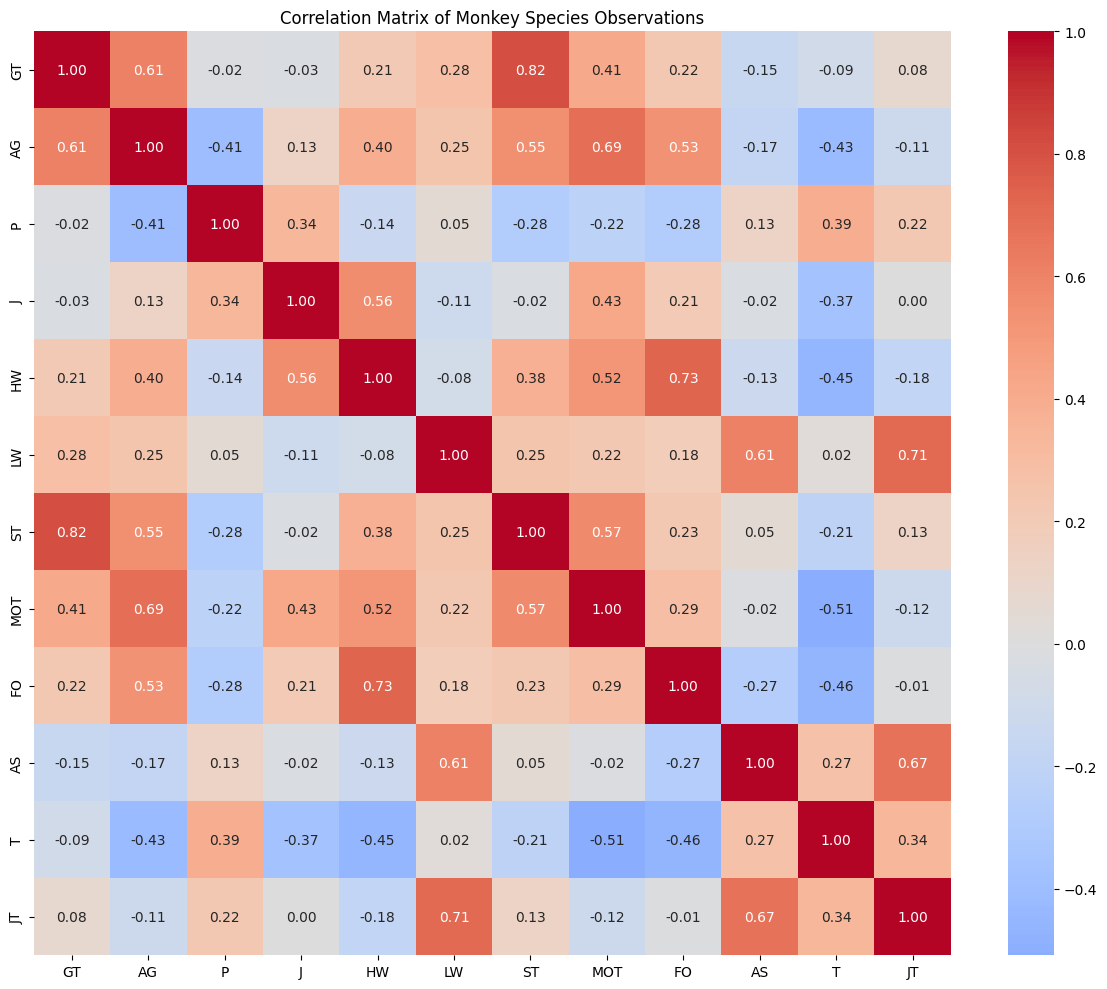

In [6]:
variable_columns = ['AC', 'AUC', 'JU', 'DB', 'CA', 'CB', 'RE', 'PA', 'FO', 'SA', 'AI', 'AMC']
english_id_columns = [spanish_to_english_id[col] for col in variable_columns]
variable_columns = english_id_columns

# Calculate correlation matrix
corr_matrix = df[variable_columns].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix of Monkey Species Observations')
plt.tight_layout()
plt.show()

In [7]:
def highlight_correlation_by_variables(corr_matrix, variable_pairs_orange=None, variable_pairs_green=None, 
                                    border_width=3):
    """
    Border specific variable pairs in the correlation matrix with different colors.
    
    Parameters:
    - corr_matrix: pandas DataFrame correlation matrix
    - variable_pairs_orange: list of tuples with variable names to border in orange
    - variable_pairs_green: list of tuples with variable names to border in green
    - border_width: width of the border line
    """
    plt.figure(figsize=(12, 10))
    
    # Create the base heatmap
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
    
    # Function to add borders using individual line segments
    def add_borders(variable_pairs, border_color):
        if variable_pairs:
            for var1, var2 in variable_pairs:
                if var1 in corr_matrix.index and var2 in corr_matrix.columns:
                    row_idx = corr_matrix.index.get_loc(var1)
                    col_idx = corr_matrix.columns.get_loc(var2)
                    
                    # Correct coordinate calculation for heatmap
                    y_pos = row_idx + 0.5
                    x_pos = col_idx + 0.5
                    
                    # Create individual line segments for each side
                    # Top border
                    plt.plot([x_pos-0.5, x_pos+0.5], [y_pos+0.5, y_pos+0.5], 
                            color=border_color, linewidth=border_width)
                    # Bottom border
                    plt.plot([x_pos-0.5, x_pos+0.5], [y_pos-0.5, y_pos-0.5], 
                            color=border_color, linewidth=border_width)
                    # Left border
                    plt.plot([x_pos-0.5, x_pos-0.5], [y_pos-0.5, y_pos+0.5], 
                            color=border_color, linewidth=border_width)
                    # Right border
                    plt.plot([x_pos+0.5, x_pos+0.5], [y_pos-0.5, y_pos+0.5], 
                            color=border_color, linewidth=border_width)
    
    # Add orange borders
    add_borders(variable_pairs_orange, '#a3386c')
    
    # Add green borders
    add_borders(variable_pairs_green, 'green')
    
    plt.title('Correlation Matrix of Monkey Species Observations')
    plt.tight_layout()
    plt.show()

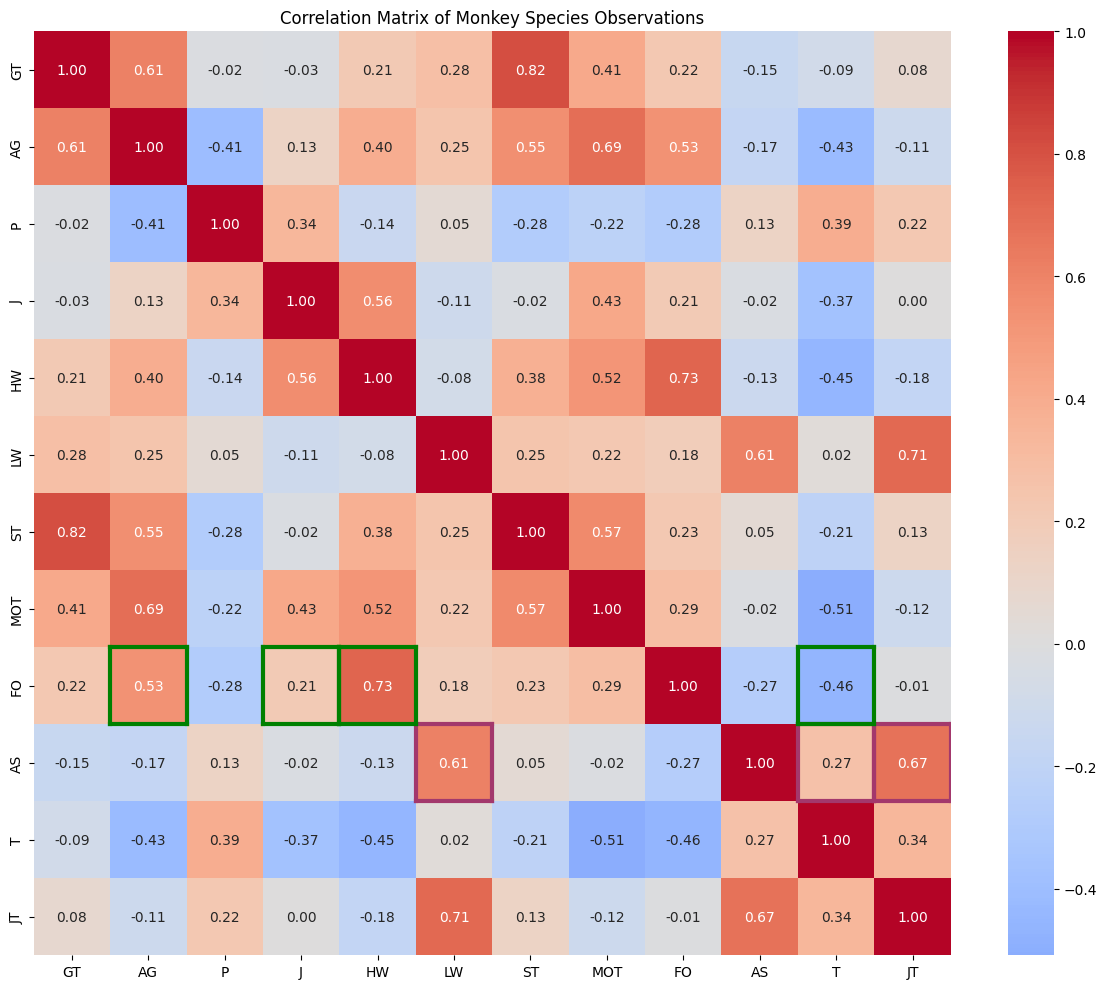

In [8]:
# Example usage with two different lists:
orange_pairs = [('AS', 'LW'), ('AS', 'JT'), ('AS', 'T')]
green_pairs = [('FO', 'HW'), ('FO', 'AG'), ('FO', 'J'), ('FO', 'T')]
highlight_correlation_by_variables(corr_matrix, variable_pairs_orange=orange_pairs, 
                                variable_pairs_green=green_pairs)

# Check Dispersion

In [ ]:
# Divide each column in variable_columns by "Tiempo Observación (minutos)" and create new columns in df
for var in variable_columns:
    df[var + '_per_min'] = df[var] / df['Tiempo Observación (minutos)']

behavior_columns = [col for col in df.columns if col.endswith('_per_min')]

In [ ]:
results = {}

for behavior in behavior_columns:
    print(f"\nAnalyzing behavior: {behavior}")
    
    # Create formula dynamically
    formula = f"{behavior} ~ Lugar + Horario + Individuals"
    
    # Fit Poisson GLM with offset
    poisson_model = smf.glm(formula=formula, data=df,
                           family=sm.families.Poisson(),
                           offset=np.log(df['Tiempo Observación (minutos)'])).fit()
    
    dispersion = poisson_model.deviance / poisson_model.df_resid
    print(f"Poisson dispersion: {dispersion:.2f}")
    
    if dispersion > 1.5:
        nb_model = smf.glm(formula=formula, data=df,
                          family=sm.families.NegativeBinomial(alpha=1.0),
                          offset=np.log(df['Tiempo Observación (minutos)'])).fit()
        print("Negative Binomial model fitted (due to overdispersion)")
        print(f"AIC Poisson: {poisson_model.aic:.2f}, AIC NegBin: {nb_model.aic:.2f}")
        
        # Choose model with lower AIC
        best_model = 'Negative Binomial' if nb_model.aic < poisson_model.aic else 'Poisson'
    else:
        print("No overdispersion detected; using Poisson model")
        best_model = 'Poisson'
    
    results[behavior] = best_model

print("\nModel selection summary for behaviors:")
for behavior, model_type in results.items():
    print(f"{behavior}: {model_type}")



Analyzing behavior: GT_per_min
Poisson dispersion: 0.07
No overdispersion detected; using Poisson model

Analyzing behavior: AG_per_min
Poisson dispersion: 0.09
No overdispersion detected; using Poisson model

Analyzing behavior: P_per_min
Poisson dispersion: 0.04
No overdispersion detected; using Poisson model

Analyzing behavior: J_per_min
Poisson dispersion: 0.19
No overdispersion detected; using Poisson model

Analyzing behavior: HW_per_min
Poisson dispersion: 0.28
No overdispersion detected; using Poisson model

Analyzing behavior: LW_per_min
Poisson dispersion: 0.16
No overdispersion detected; using Poisson model

Analyzing behavior: ST_per_min
Poisson dispersion: 0.11
No overdispersion detected; using Poisson model

Analyzing behavior: MOT_per_min
Poisson dispersion: 0.28
No overdispersion detected; using Poisson model

Analyzing behavior: FO_per_min
Poisson dispersion: 0.32
No overdispersion detected; using Poisson model

Analyzing behavior: AS_per_min
Poisson dispersion: 0.11

# Bar Plots

In [71]:
def analyze_by_category(df, category_col, value_cols, covariates, offset_col, significance_threshold=0.05):
    """
    Analyze differences in value columns grouped by a category column using Poisson GLMs.
    Falls back to Fisher's exact test when one category has all zeros for a behavior.
    Shows violin plots with mean and min/max only (no median).
    """
    import statsmodels.api as sm
    import statsmodels.formula.api as smf
    from scipy.stats import fisher_exact

    categories = df[category_col].unique()
    colors = sns.color_palette("husl", len(categories))

    n_rows = 5
    n_cols = 3
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 30))
    axes = axes.flatten()

    for idx, col in enumerate(value_cols):
        if idx < len(axes):
            ax = axes[idx]

            # Prepare data for violin plot
            plot_data = []
            plot_labels = []
            for cat in categories:
                cat_data = df[df[category_col] == cat][col].values
                plot_data.append(cat_data)
                plot_labels.append(cat)

            # Create violin plot without showing median, just mean, min, max
            parts = ax.violinplot(
                plot_data, 
                positions=range(len(categories)), 
                showmeans=True, 
                showmedians=False # Don't plot the median
            )

            # Customize violin plot colors
            for pc, color in zip(parts['bodies'], colors):
                pc.set_facecolor(color)
                pc.set_alpha(0.7)

            # Set style for cmeans, cmins, cmaxes only (no cmedians)
            for partname in ('cbars', 'cmins', 'cmaxes', 'cmeans'):
                if partname in parts:
                    parts[partname].set_color('black')
                    parts[partname].set_linewidth(1)

            # Legend removed as per instructions

            # Check if any category has all zeros
            category_has_all_zeros = False
            for cat in categories:
                cat_data = df[df[category_col] == cat][col]
                if len(cat_data) > 0 and cat_data.sum() == 0:
                    category_has_all_zeros = True
                    break

            if category_has_all_zeros and len(categories) == 2:
                # Use Fisher's exact test for 2-category comparison with zeros
                cat1_data = df[df[category_col] == categories[0]][col]
                cat2_data = df[df[category_col] == categories[1]][col]

                # Create 2x2 contingency table: presence/absence vs category
                cat1_present = (cat1_data > 0).sum()
                cat1_absent = (cat1_data == 0).sum()
                cat2_present = (cat2_data > 0).sum()
                cat2_absent = (cat2_data == 0).sum()

                contingency_table = [[cat1_present, cat1_absent],
                                     [cat2_present, cat2_absent]]

                try:
                    oddsratio, p_value = fisher_exact(contingency_table)
                    min_p = p_value
                    model_type = "Fisher's Exact Test"
                except Exception as e:
                    min_p = np.nan
                    model_type = "Test failed"
            else:
                # Use Poisson GLM
                covariate_terms = " + ".join(covariates)
                formula = f"{col} ~ {category_col} + {covariate_terms}"

                try:
                    poisson_model = smf.glm(formula=formula, data=df,
                                           family=sm.families.Poisson(),
                                           offset=np.log(df[offset_col])).fit()

                    loc_pvalues = poisson_model.pvalues.filter(like=category_col)

                    # Handle Series properly
                    if isinstance(loc_pvalues, pd.Series):
                        min_p = min(loc_pvalues.values) if not loc_pvalues.empty else np.nan
                    else:
                        min_p = np.nan

                    model_type = "Poisson GLMs"

                except Exception as e:
                    min_p = np.nan
                    model_type = "Poisson (failed)"

            # --- CHANGED: Extract original id before _ for title mapping ---
            # E.g. for "AC_per_min", take "AC" and map with english_id_to_fullname
            col_base = col.split('_')[0]
            behavior_name = english_id_to_fullname.get(col_base, col_base)
            title = f"{behavior_name}\n({model_type}, p={min_p:.3f})"
            ax.set_title(title, fontsize=18)

            ax.set_xticks(range(len(categories)))
            ax.set_xticklabels(categories, rotation=0, fontsize=15)
            ax.set_ylabel('Behavior count / min', fontsize=15)
            ax.grid(axis='y', alpha=0.3)

    for idx in range(len(value_cols), len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.show()

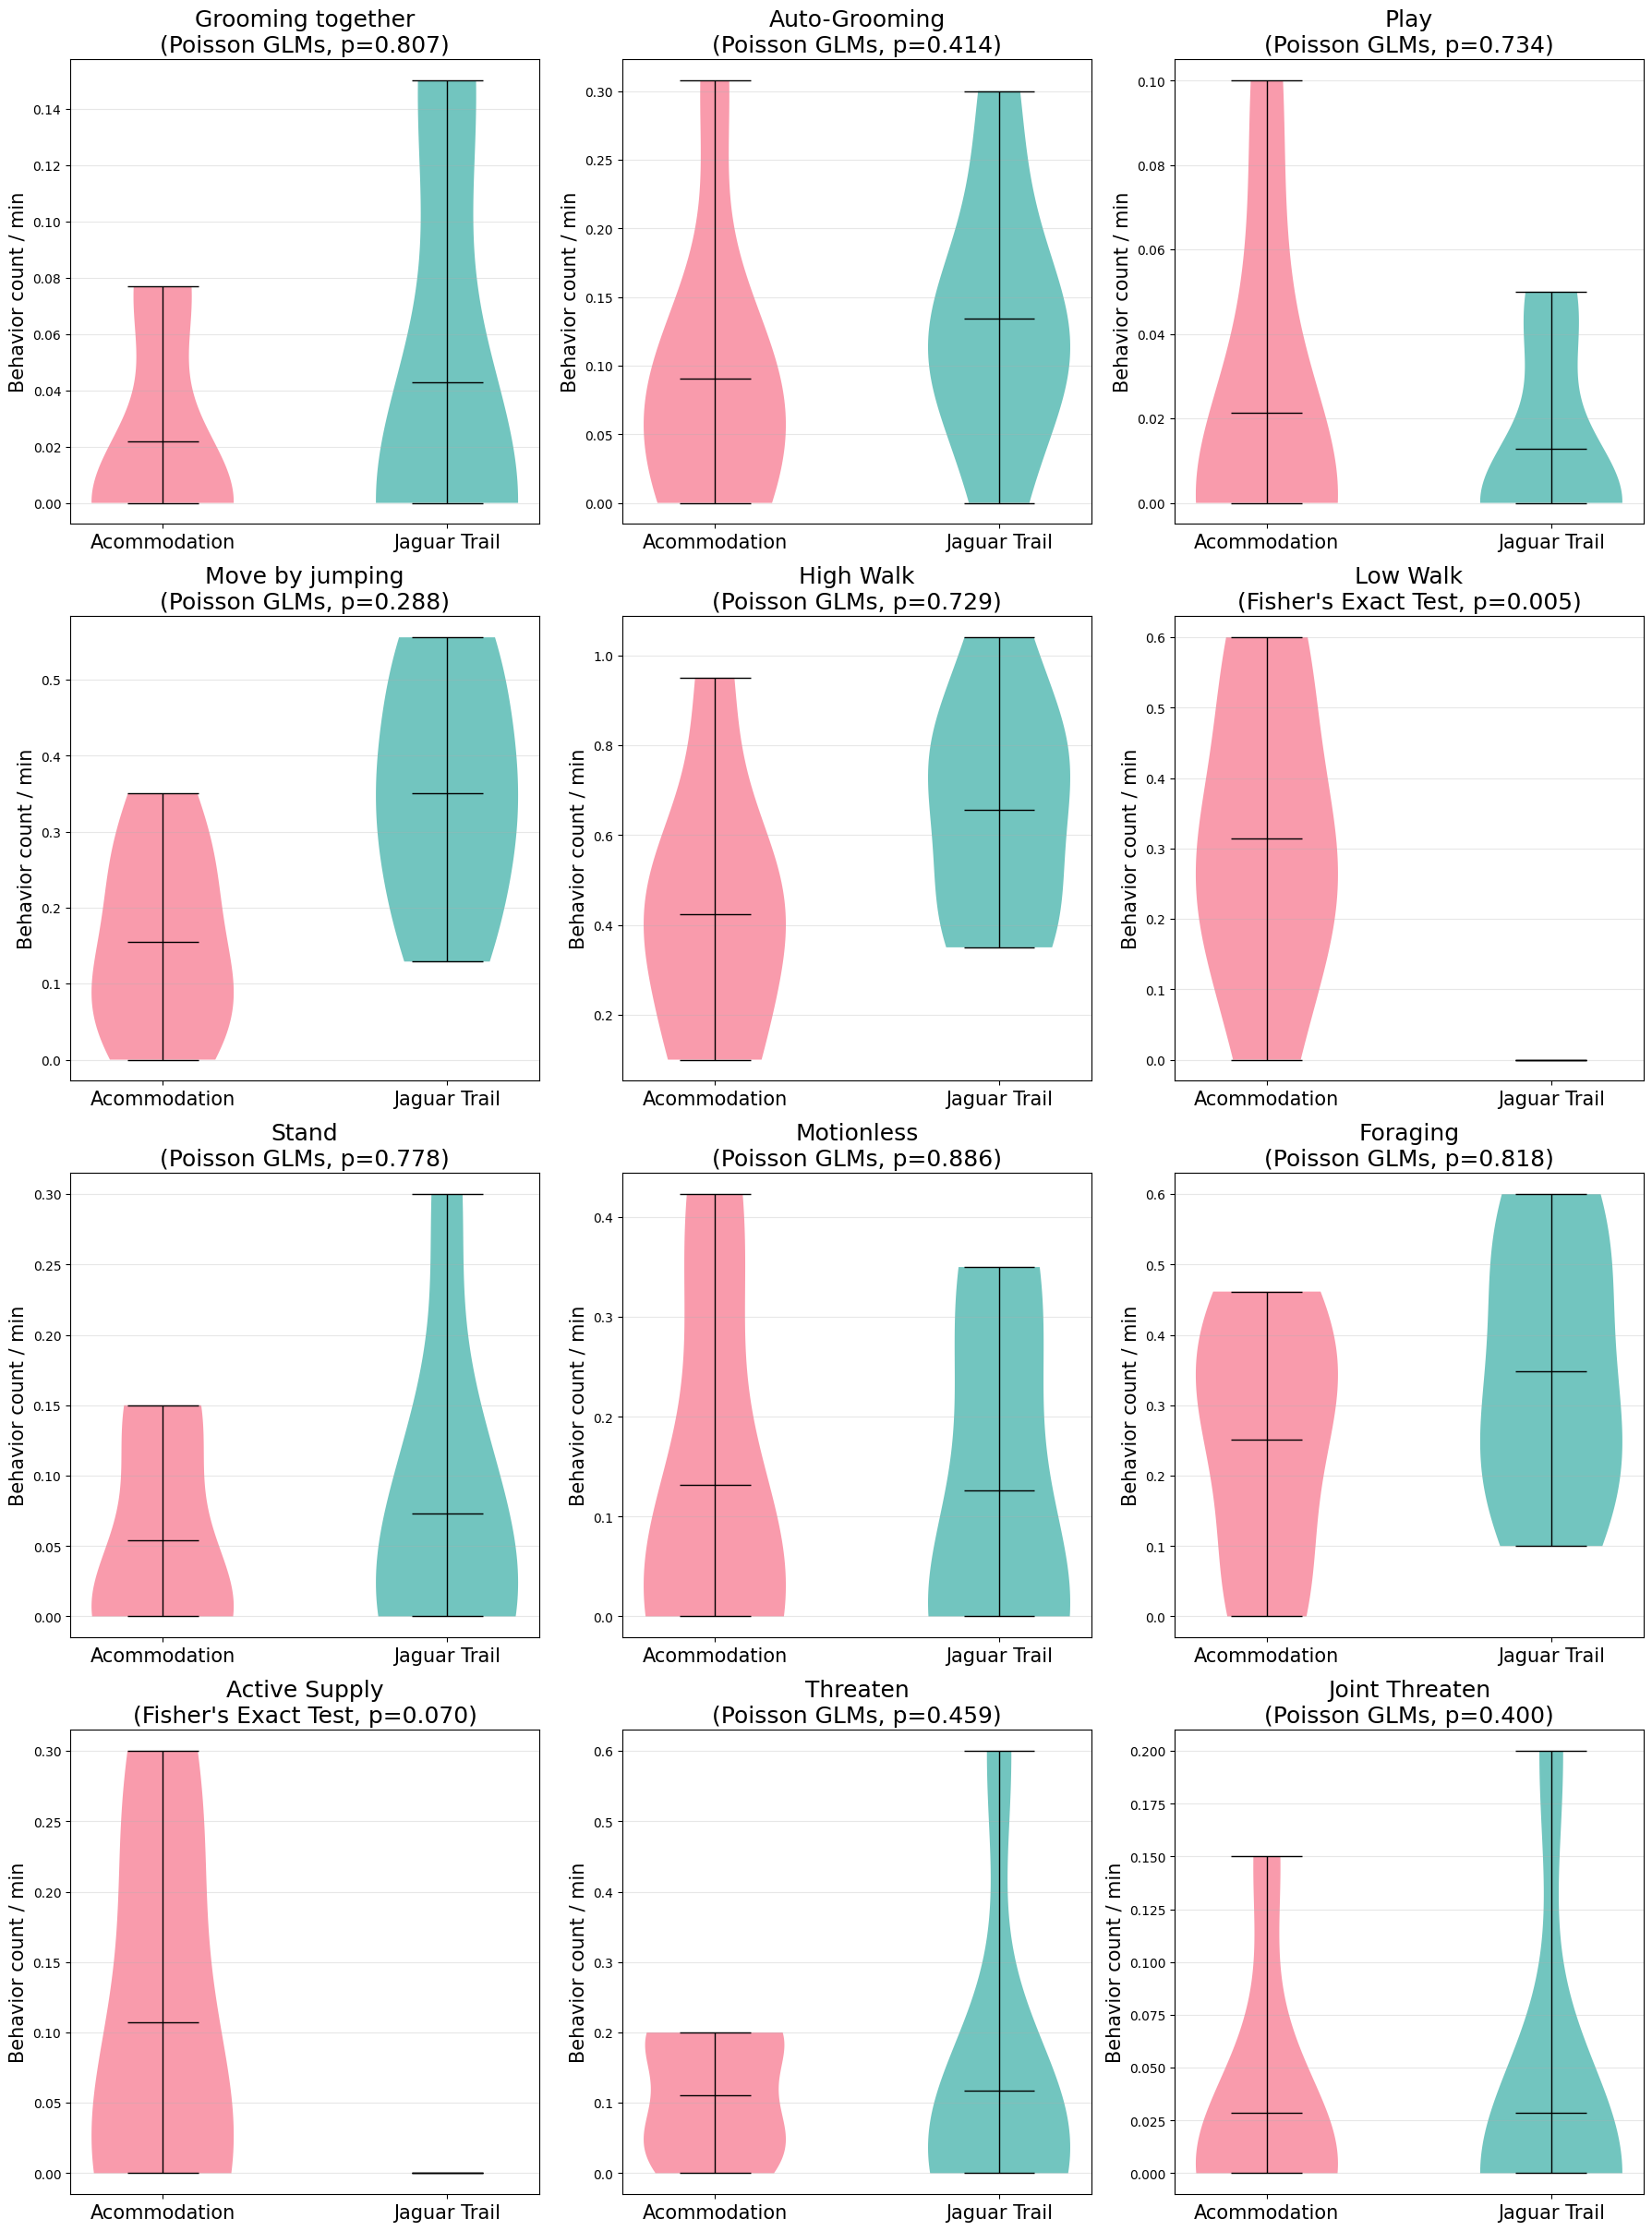

In [72]:
# Example call:
covariates = ['Horario', 'Individuals']
analyze_by_category(df, 'Lugar', behavior_columns, covariates, 'Tiempo Observación (minutos)')